# Six-Gesture Model Training

This notebook trains and evaluates the predefined six-gesture classifier using the cleaned v2 Apple Watch IMU dataset.

Gestures/classes:

- `leaf`
- `tree`
- `bird`
- `ocean`
- `river`
- `rain`

The key metric is **leave-one-participant-out macro F1**, because that shows how well the model handles a participant it has not seen during training.

## Visual-First Reading Guide

Use the plots as the main explanation. This notebook shows dataset balance, model comparison, per-class metrics, participant-held-out results, confusion matrices, normalized confusion matrices, and a final all-in-one visual dashboard for the selected model.

In [1]:
import json
import pickle
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

## Plotting Helpers

Run this cell before any chart cells. It defines shared plotting functions used throughout the notebook.

In [2]:
def style_axes(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, fontsize=12, weight="bold")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_bar_labels(ax, fmt="{:.2f}"):
    for patch in ax.patches:
        height = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=8,
        )


def normalized_confusion(matrix):
    matrix = np.array(matrix, dtype=float)
    row_sums = matrix.sum(axis=1, keepdims=True)
    return np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums != 0)


def plot_confusion_matrix(matrix, title, normalized=False, cmap="Blues"):
    values = normalized_confusion(matrix) if normalized else np.array(matrix)
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(values, cmap=cmap, vmin=0 if normalized else None, vmax=1 if normalized else None)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=12, weight="bold")
    threshold = values.max() / 2 if values.size else 0
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            text = f"{values[row, col]:.2f}" if normalized else str(int(values[row, col]))
            ax.text(
                col,
                row,
                text,
                ha="center",
                va="center",
                color="white" if values[row, col] > threshold else "black",
                fontsize=8,
            )
    fig.tight_layout()
    plt.show()


def plot_metric_heatmap(matrix, row_labels, column_labels, title, cmap="YlGnBu"):
    matrix = np.array(matrix, dtype=float)
    fig, ax = plt.subplots(figsize=(8, 5))
    image = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=1)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(len(column_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(column_labels, rotation=30, ha="right")
    ax.set_yticklabels(row_labels)
    ax.set_title(title, fontsize=12, weight="bold")
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, f"{matrix[row, col]:.2f}", ha="center", va="center", fontsize=9)
    fig.tight_layout()
    plt.show()

## Configuration

The notebook uses the cleaned v2 training file if it exists. That file is generated from the combined participant dataset after motion-quality and class-outlier filtering.

In [3]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

CLEANED_DATASET = ROOT / "data" / "cleaned_training_v2" / "cleaned_training_samples_full.json"
COMBINED_DATASET = ROOT / "data" / "New training set" / "combined_training_samples_full.json"
REPORT_PATH = ROOT / "outputs" / "six_gesture_model_report.json"
MODEL_PATH = ROOT / "models" / "six_gesture_final_model.pkl"

CHANNELS = ["ax", "ay", "az", "gx", "gy", "gz"]
TARGET_FRAMES = 128
SEQUENCE_FRAMES = 64
GENERATED_ON = "2026-05-25"

DATASET_PATH = CLEANED_DATASET if CLEANED_DATASET.exists() else COMBINED_DATASET
DATASET_PATH

WindowsPath('C:/Users/USER/Desktop/G2A/data/cleaned_training_v2/cleaned_training_samples_full.json')

## Load Dataset

In [4]:
with DATASET_PATH.open("r", encoding="utf-8") as handle:
    payload = json.load(handle)

labels = payload["labels"]
samples = payload["samples"]
label_to_index = {label: index for index, label in enumerate(labels)}

label_counts = Counter(sample["label"] for sample in samples)
participant_counts = Counter(sample["participant"] for sample in samples)

print("source:", DATASET_PATH.relative_to(ROOT).as_posix())
print("samples:", len(samples))
print("labels:", labels)
print("label counts:", dict(label_counts))
print("participant counts:", dict(participant_counts))

source: data/cleaned_training_v2/cleaned_training_samples_full.json
samples: 940
labels: ['leaf', 'tree', 'bird', 'ocean', 'river', 'rain']
label counts: {'leaf': 153, 'tree': 159, 'bird': 154, 'ocean': 157, 'river': 160, 'rain': 157}
participant counts: {'Nilakna': 117, 'Nilesh': 144, 'Cerella': 150, 'Hong': 106, 'Nathalie': 137, 'Oshadha': 148, 'Rakesh': 138}


## Dataset Distribution Charts

These plots show whether the cleaned dataset is balanced across gestures and participants.

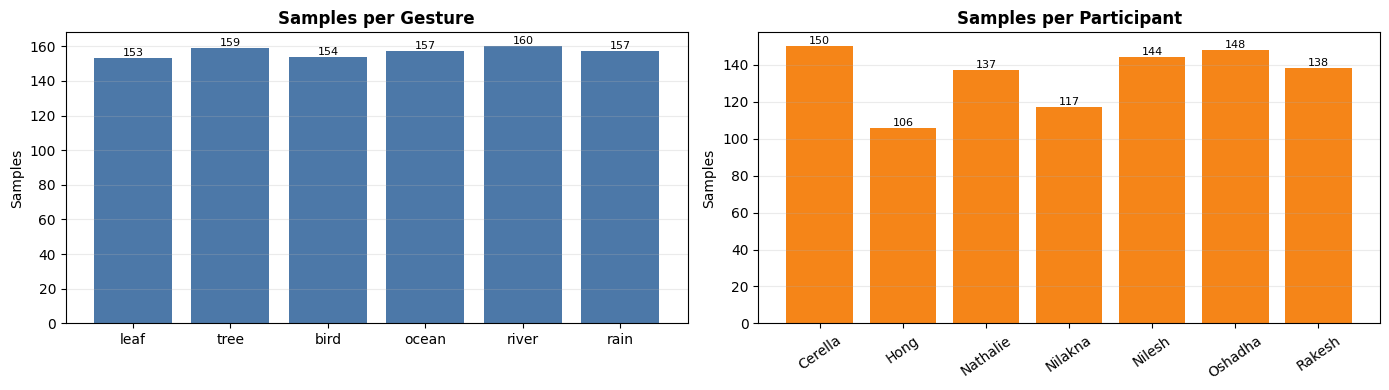

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

class_names = labels
class_values = [label_counts[label] for label in class_names]
axes[0].bar(class_names, class_values, color="#4C78A8")
axes[0].set_title("Samples per Gesture", fontsize=12, weight="bold")
axes[0].set_ylabel("Samples")
axes[0].grid(axis="y", alpha=0.25)
for patch in axes[0].patches:
    axes[0].text(patch.get_x() + patch.get_width()/2, patch.get_height(), int(patch.get_height()), ha="center", va="bottom", fontsize=8)

participant_names = sorted(participant_counts)
participant_values = [participant_counts[name] for name in participant_names]
axes[1].bar(participant_names, participant_values, color="#F58518")
axes[1].set_title("Samples per Participant", fontsize=12, weight="bold")
axes[1].set_ylabel("Samples")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", alpha=0.25)
for patch in axes[1].patches:
    axes[1].text(patch.get_x() + patch.get_width()/2, patch.get_height(), int(patch.get_height()), ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()

## Feature Extraction

The model does not use raw frames directly. Each sample is converted into engineered IMU features:

- resampled six-axis sequence
- acceleration and gyroscope magnitudes
- first and second derivatives
- summary statistics
- channel correlations
- a compact low-resolution sequence slice

In [6]:
def sample_to_array(sample):
    arr = np.array(
        [[frame[channel] for channel in CHANNELS] for frame in sample["frames"]],
        dtype=np.float32,
    )
    return arr - arr[:5].mean(axis=0, keepdims=True)


def resample_array(arr, target):
    if len(arr) == target:
        return arr.astype(np.float32)
    old_x = np.linspace(0, 1, len(arr))
    new_x = np.linspace(0, 1, target)
    return np.stack(
        [np.interp(new_x, old_x, arr[:, column]) for column in range(arr.shape[1])],
        axis=1,
    ).astype(np.float32)


def feature_vector(arr):
    resampled = resample_array(arr, TARGET_FRAMES)
    acc_mag = np.linalg.norm(resampled[:, :3], axis=1, keepdims=True)
    gyro_mag = np.linalg.norm(resampled[:, 3:], axis=1, keepdims=True)
    signals = np.concatenate([resampled, acc_mag, gyro_mag], axis=1)
    delta = np.diff(signals, axis=0)
    delta2 = np.diff(delta, axis=0)

    features = []
    for block in [signals, delta, delta2]:
        features.extend(block.mean(axis=0))
        features.extend(block.std(axis=0))
        features.extend(block.min(axis=0))
        features.extend(block.max(axis=0))
        features.extend(np.percentile(block, [10, 25, 50, 75, 90], axis=0).ravel())
        features.extend((block * block).mean(axis=0))

    corr = np.nan_to_num(np.corrcoef(signals.T))
    features.extend(corr[np.triu_indices(corr.shape[0], 1)])
    features.extend(resample_array(arr, SEQUENCE_FRAMES).ravel())
    return np.array(features, dtype=np.float32)

In [7]:
X = np.vstack([feature_vector(sample_to_array(sample)) for sample in samples])
y = np.array([label_to_index[sample["label"]] for sample in samples])
participants = np.array([sample["participant"] for sample in samples])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (940, 652)
y shape: (940,)


## Metric Helpers

In [8]:
def metrics_dict(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        "classification_report": classification_report(
            y_true,
            y_pred,
            target_names=labels,
            output_dict=True,
            zero_division=0,
        ),
    }


def print_metric_summary(name, result):
    random_result = result["random_holdout"]
    lopo_result = result["leave_one_participant_out"]
    print(
        f"{name:25s} | "
        f"random acc {random_result['accuracy']:.3f} | "
        f"random F1 {random_result['macro_f1']:.3f} | "
        f"LOPO acc {lopo_result['accuracy']:.3f} | "
        f"LOPO F1 {lopo_result['macro_f1']:.3f}"
    )

## Candidate Models

The final model is selected by leave-one-participant-out macro F1.

In [9]:
def candidate_models():
    return {
        "kbest200_logistic_regression": make_pipeline(
            StandardScaler(),
            SelectKBest(f_classif, k=200),
            LogisticRegression(C=0.5, max_iter=3000, class_weight="balanced", random_state=42),
        ),
        "pca_logistic_regression": make_pipeline(
            StandardScaler(),
            PCA(n_components=0.95, random_state=42),
            LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
        ),
        "linear_svc": make_pipeline(
            StandardScaler(),
            LinearSVC(C=0.2, class_weight="balanced", max_iter=10000, dual=False),
        ),
        "rbf_svc": make_pipeline(
            StandardScaler(),
            PCA(n_components=0.95, random_state=42),
            SVC(C=3.0, gamma="scale", class_weight="balanced"),
        ),
        "ridge_classifier": make_pipeline(
            StandardScaler(),
            RidgeClassifier(class_weight="balanced"),
        ),
        "extra_trees": ExtraTreesClassifier(
            n_estimators=700,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=700,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    }


## Evaluation Function

This reports both random holdout and leave-one-participant-out results.

Random holdout is useful for checking whether the classes are separable at all. Leave-one-participant-out is the more important test because it measures generalization to unseen users.

In [10]:
def evaluate_model(model):
    train_idx, test_idx = train_test_split(
        np.arange(len(y)),
        test_size=0.2,
        random_state=42,
        stratify=y,
    )
    model.fit(X[train_idx], y[train_idx])
    random_pred = model.predict(X[test_idx])

    lopo_true = []
    lopo_pred = []
    by_participant = {}

    for participant in sorted(set(participants)):
        train_mask = participants != participant
        test_mask = participants == participant
        model.fit(X[train_mask], y[train_mask])
        pred = model.predict(X[test_mask])
        by_participant[str(participant)] = {
            "sample_count": int(test_mask.sum()),
            **metrics_dict(y[test_mask], pred),
        }
        lopo_true.extend(y[test_mask])
        lopo_pred.extend(pred)

    return {
        "random_holdout": metrics_dict(y[test_idx], random_pred),
        "leave_one_participant_out": {
            **metrics_dict(np.array(lopo_true), np.array(lopo_pred)),
            "by_participant": by_participant,
        },
    }

## Train And Compare Models

In [11]:
results = {}
for name, model in candidate_models().items():
    print(f"training {name}")
    results[name] = evaluate_model(model)

print()
print("Summary")
for name, result in results.items():
    print_metric_summary(name, result)

training kbest200_logistic_regression


training pca_logistic_regression


training linear_svc


training rbf_svc


training ridge_classifier


training extra_trees


training random_forest



Summary
kbest200_logistic_regression | random acc 0.851 | random F1 0.852 | LOPO acc 0.520 | LOPO F1 0.522
pca_logistic_regression   | random acc 0.723 | random F1 0.724 | LOPO acc 0.480 | LOPO F1 0.478
linear_svc                | random acc 0.793 | random F1 0.793 | LOPO acc 0.454 | LOPO F1 0.451
rbf_svc                   | random acc 0.809 | random F1 0.808 | LOPO acc 0.378 | LOPO F1 0.378
ridge_classifier          | random acc 0.691 | random F1 0.694 | LOPO acc 0.386 | LOPO F1 0.389
extra_trees               | random acc 0.846 | random F1 0.847 | LOPO acc 0.402 | LOPO F1 0.391
random_forest             | random acc 0.835 | random F1 0.836 | LOPO acc 0.418 | LOPO F1 0.406


## Model Comparison Charts

The selected model should be judged mainly by LOPO macro F1 because that tests unseen participants.

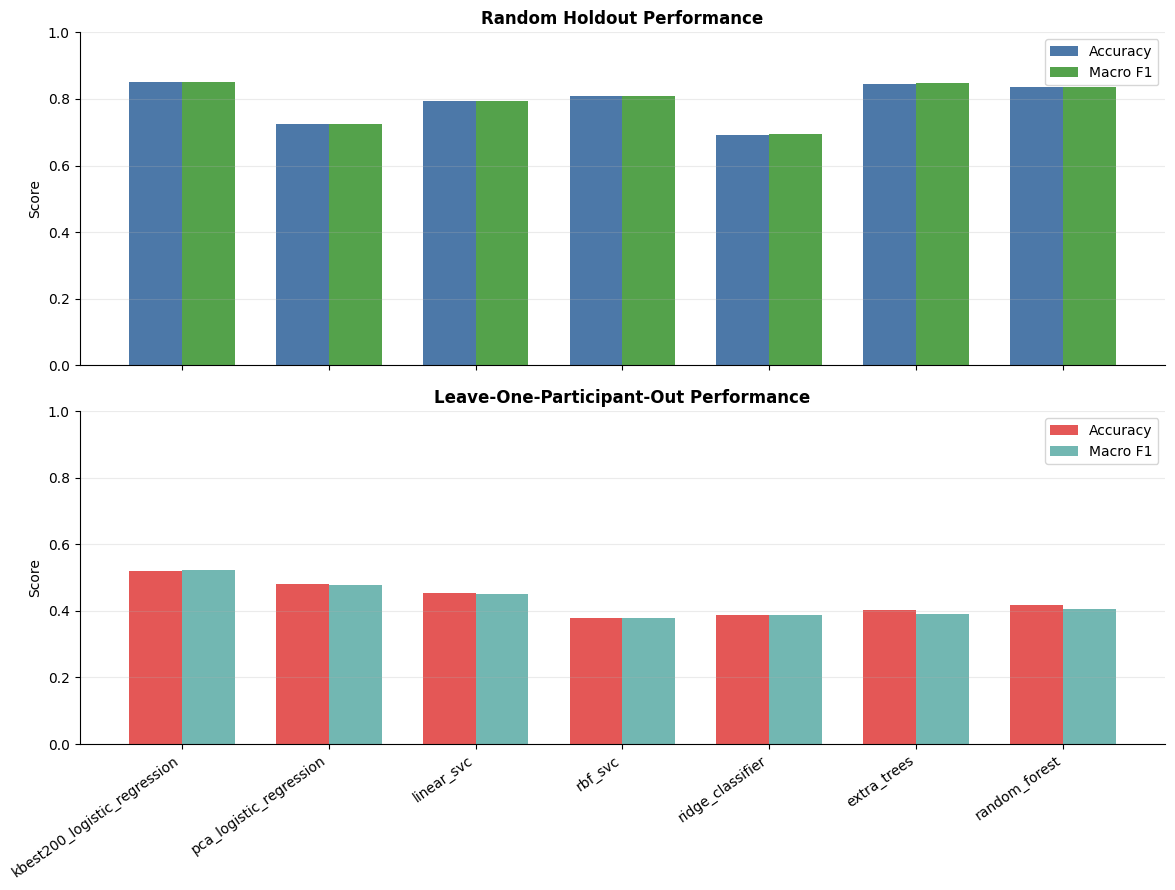

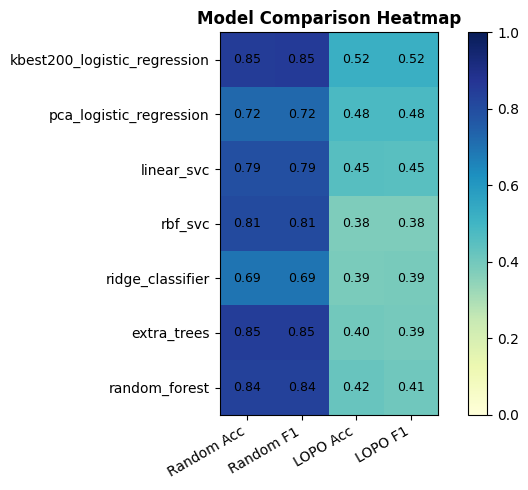

In [12]:
model_names = list(results.keys())
random_acc = [results[name]["random_holdout"]["accuracy"] for name in model_names]
random_f1 = [results[name]["random_holdout"]["macro_f1"] for name in model_names]
lopo_acc = [results[name]["leave_one_participant_out"]["accuracy"] for name in model_names]
lopo_f1 = [results[name]["leave_one_participant_out"]["macro_f1"] for name in model_names]

xpos = np.arange(len(model_names))
width = 0.36
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
axes[0].bar(xpos - width/2, random_acc, width, label="Accuracy", color="#4C78A8")
axes[0].bar(xpos + width/2, random_f1, width, label="Macro F1", color="#54A24B")
style_axes(axes[0], "Random Holdout Performance", ylabel="Score")
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(xpos - width/2, lopo_acc, width, label="Accuracy", color="#E45756")
axes[1].bar(xpos + width/2, lopo_f1, width, label="Macro F1", color="#72B7B2")
style_axes(axes[1], "Leave-One-Participant-Out Performance", ylabel="Score")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(model_names, rotation=35, ha="right")
axes[1].legend()
fig.tight_layout()
plt.show()

comparison_matrix = [[random_acc[i], random_f1[i], lopo_acc[i], lopo_f1[i]] for i in range(len(model_names))]
plot_metric_heatmap(comparison_matrix, model_names, ["Random Acc", "Random F1", "LOPO Acc", "LOPO F1"], "Model Comparison Heatmap")

## Select Best Model

In [13]:
selected_model_name = max(
    results,
    key=lambda name: results[name]["leave_one_participant_out"]["macro_f1"],
)
selected_result = results[selected_model_name]

print("selected model:", selected_model_name)
print("random holdout:", selected_result["random_holdout"])
print("leave-one-participant-out:", {
    key: value
    for key, value in selected_result["leave_one_participant_out"].items()
    if key != "by_participant"
})

selected model: kbest200_logistic_regression
random holdout: {'accuracy': 0.851063829787234, 'macro_f1': 0.8522346866096866, 'weighted_f1': 0.852315477814148, 'macro_precision': 0.854821855934203, 'macro_recall': 0.8509744623655915, 'confusion_matrix': [[25, 0, 0, 5, 0, 1], [0, 28, 0, 1, 3, 0], [1, 1, 26, 0, 3, 0], [5, 0, 0, 26, 0, 0], [1, 1, 2, 1, 27, 0], [1, 1, 1, 0, 0, 28]], 'classification_report': {'leaf': {'precision': 0.7575757575757576, 'recall': 0.8064516129032258, 'f1-score': 0.78125, 'support': 31.0}, 'tree': {'precision': 0.9032258064516129, 'recall': 0.875, 'f1-score': 0.8888888888888888, 'support': 32.0}, 'bird': {'precision': 0.896551724137931, 'recall': 0.8387096774193549, 'f1-score': 0.8666666666666667, 'support': 31.0}, 'ocean': {'precision': 0.7878787878787878, 'recall': 0.8387096774193549, 'f1-score': 0.8125, 'support': 31.0}, 'river': {'precision': 0.8181818181818182, 'recall': 0.84375, 'f1-score': 0.8307692307692308, 'support': 32.0}, 'rain': {'precision': 0.96551

## Per-Class F1 Scores

In [14]:
print("Random holdout per-class scores")
for label in labels:
    row = selected_result["random_holdout"]["classification_report"][label]
    print(label, "precision", round(row["precision"], 3), "recall", round(row["recall"], 3), "f1", round(row["f1-score"], 3), "support", row["support"])

print()
print("Leave-one-participant-out per-class scores")
for label in labels:
    row = selected_result["leave_one_participant_out"]["classification_report"][label]
    print(label, "precision", round(row["precision"], 3), "recall", round(row["recall"], 3), "f1", round(row["f1-score"], 3), "support", row["support"])

Random holdout per-class scores
leaf precision 0.758 recall 0.806 f1 0.781 support 31.0
tree precision 0.903 recall 0.875 f1 0.889 support 32.0
bird precision 0.897 recall 0.839 f1 0.867 support 31.0
ocean precision 0.788 recall 0.839 f1 0.812 support 31.0
river precision 0.818 recall 0.844 f1 0.831 support 32.0
rain precision 0.966 recall 0.903 f1 0.933 support 31.0

Leave-one-participant-out per-class scores
leaf precision 0.315 recall 0.294 f1 0.304 support 153.0
tree precision 0.641 recall 0.585 f1 0.612 support 159.0
bird precision 0.403 recall 0.552 f1 0.466 support 154.0
ocean precision 0.569 recall 0.554 f1 0.561 support 157.0
river precision 0.476 recall 0.438 f1 0.456 support 160.0
rain precision 0.773 recall 0.694 f1 0.732 support 157.0


## Participant-Held-Out Scores

In [15]:
for participant, row in selected_result["leave_one_participant_out"]["by_participant"].items():
    print(
        participant,
        "n", row["sample_count"],
        "accuracy", round(row["accuracy"], 3),
        "macro_f1", round(row["macro_f1"], 3),
    )

Cerella n 150 accuracy 0.613 macro_f1 0.591
Hong n 106 accuracy 0.481 macro_f1 0.396
Nathalie n 137 accuracy 0.438 macro_f1 0.355
Nilakna n 117 accuracy 0.487 macro_f1 0.418
Nilesh n 144 accuracy 0.75 macro_f1 0.689
Oshadha n 148 accuracy 0.5 macro_f1 0.505
Rakesh n 138 accuracy 0.341 macro_f1 0.226


## Confusion Matrices

Rows are true labels. Columns are predicted labels.

In [16]:
print("labels:", labels)
print()
print("Random holdout confusion matrix")
print(np.array(selected_result["random_holdout"]["confusion_matrix"]))

print()
print("Leave-one-participant-out confusion matrix")
print(np.array(selected_result["leave_one_participant_out"]["confusion_matrix"]))

labels: ['leaf', 'tree', 'bird', 'ocean', 'river', 'rain']

Random holdout confusion matrix
[[25  0  0  5  0  1]
 [ 0 28  0  1  3  0]
 [ 1  1 26  0  3  0]
 [ 5  0  0 26  0  0]
 [ 1  1  2  1 27  0]
 [ 1  1  1  0  0 28]]

Leave-one-participant-out confusion matrix
[[ 45  21  24  35  20   8]
 [ 20  93  16  13  15   2]
 [ 14  13  85  11  17  14]
 [ 32   4  24  87   9   1]
 [ 21  11  45   6  70   7]
 [ 11   3  17   1  16 109]]


## Selected Model Visual Analysis

These plots explain the selected model without needing to read raw printed metrics.

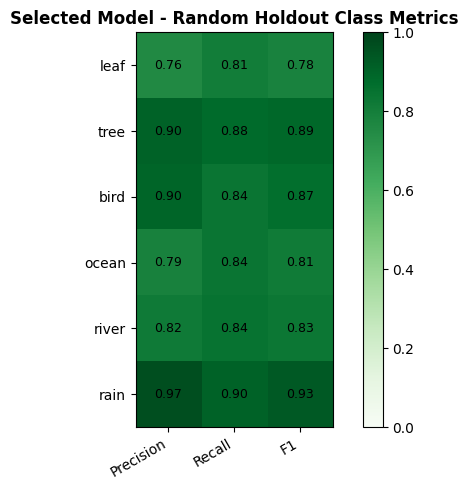

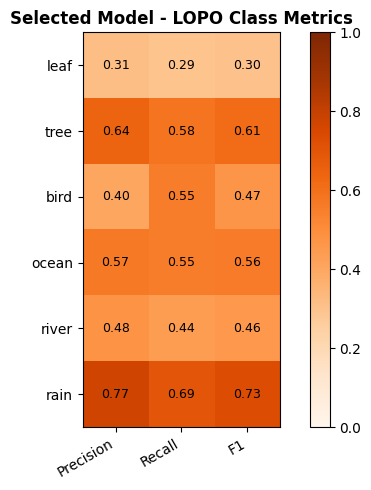

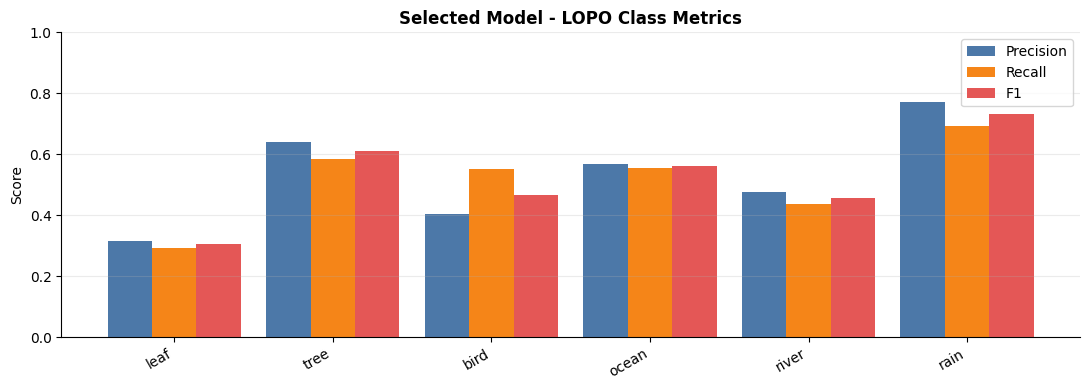

In [17]:
random_report = selected_result["random_holdout"]["classification_report"]
lopo_report = selected_result["leave_one_participant_out"]["classification_report"]

random_precision_by_class = [random_report[label]["precision"] for label in labels]
random_recall_by_class = [random_report[label]["recall"] for label in labels]
random_f1_by_class = [random_report[label]["f1-score"] for label in labels]
lopo_precision_by_class = [lopo_report[label]["precision"] for label in labels]
lopo_recall_by_class = [lopo_report[label]["recall"] for label in labels]
lopo_f1_by_class = [lopo_report[label]["f1-score"] for label in labels]

plot_metric_heatmap(
    [[random_precision_by_class[i], random_recall_by_class[i], random_f1_by_class[i]] for i in range(len(labels))],
    labels,
    ["Precision", "Recall", "F1"],
    "Selected Model - Random Holdout Class Metrics",
    cmap="Greens",
)

plot_metric_heatmap(
    [[lopo_precision_by_class[i], lopo_recall_by_class[i], lopo_f1_by_class[i]] for i in range(len(labels))],
    labels,
    ["Precision", "Recall", "F1"],
    "Selected Model - LOPO Class Metrics",
    cmap="Oranges",
)

xpos = np.arange(len(labels))
width = 0.28
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(xpos - width, lopo_precision_by_class, width, label="Precision", color="#4C78A8")
ax.bar(xpos, lopo_recall_by_class, width, label="Recall", color="#F58518")
ax.bar(xpos + width, lopo_f1_by_class, width, label="F1", color="#E45756")
style_axes(ax, "Selected Model - LOPO Class Metrics", ylabel="Score")
ax.set_ylim(0, 1)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.legend()
fig.tight_layout()
plt.show()

## Selected Model Confusion Matrix Plots

The normalized matrices are often easier to understand than raw counts because each row sums to 1.

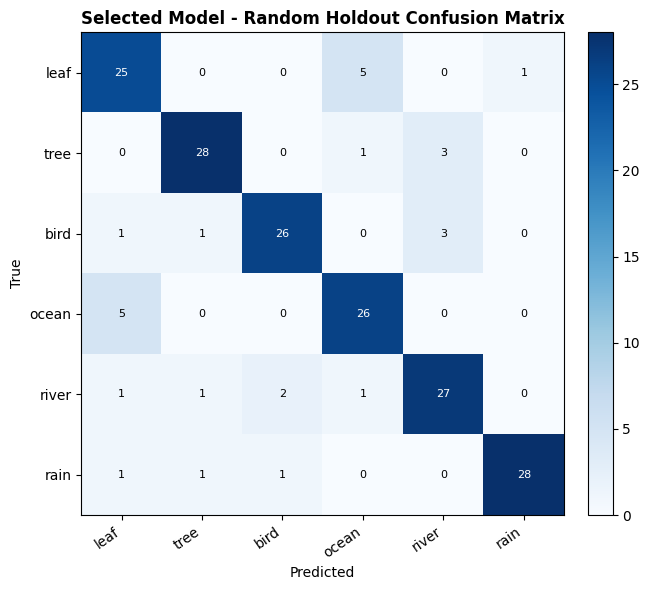

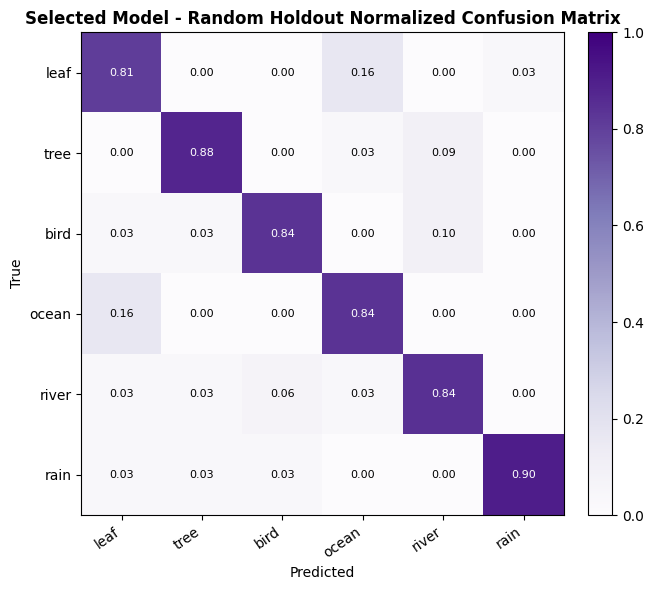

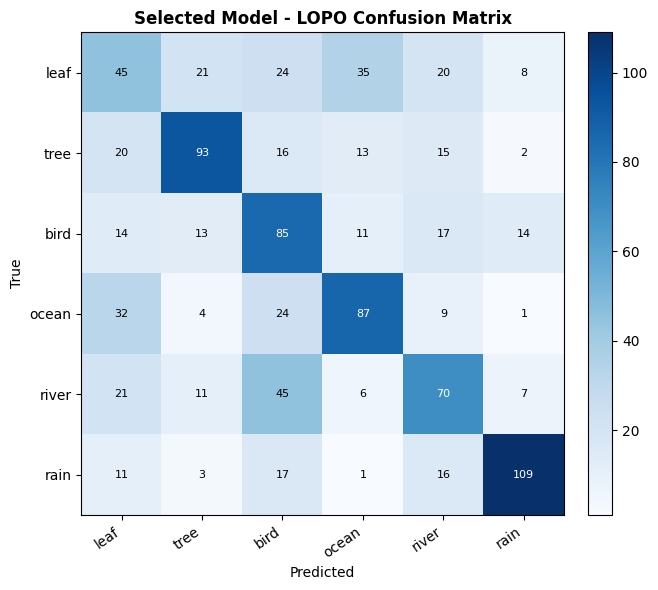

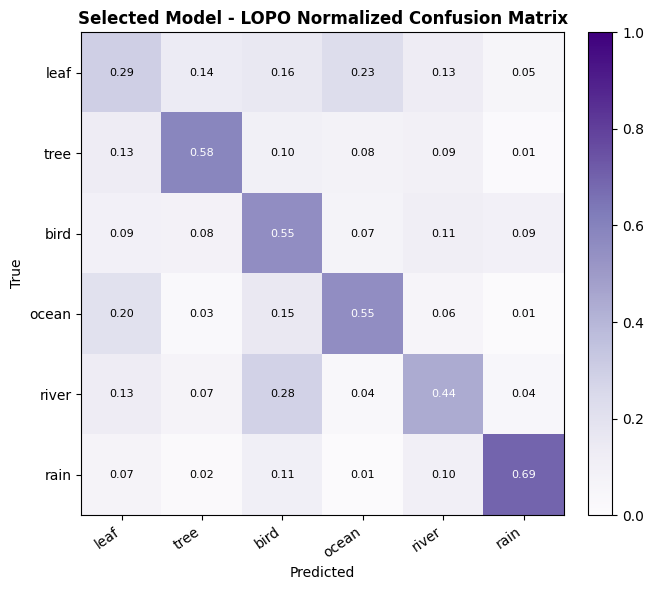

In [18]:
plot_confusion_matrix(selected_result["random_holdout"]["confusion_matrix"], "Selected Model - Random Holdout Confusion Matrix", normalized=False, cmap="Blues")
plot_confusion_matrix(selected_result["random_holdout"]["confusion_matrix"], "Selected Model - Random Holdout Normalized Confusion Matrix", normalized=True, cmap="Purples")
plot_confusion_matrix(selected_result["leave_one_participant_out"]["confusion_matrix"], "Selected Model - LOPO Confusion Matrix", normalized=False, cmap="Blues")
plot_confusion_matrix(selected_result["leave_one_participant_out"]["confusion_matrix"], "Selected Model - LOPO Normalized Confusion Matrix", normalized=True, cmap="Purples")

## Selected Model Participant-Held-Out Plot

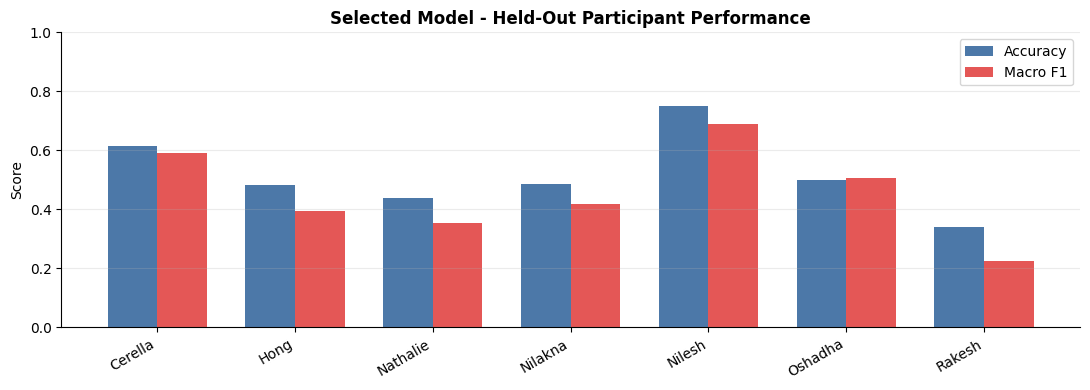

In [19]:
participant_rows = selected_result["leave_one_participant_out"]["by_participant"]
participant_names = list(participant_rows.keys())
participant_acc = [participant_rows[name]["accuracy"] for name in participant_names]
participant_f1 = [participant_rows[name]["macro_f1"] for name in participant_names]

xpos = np.arange(len(participant_names))
width = 0.36
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(xpos - width/2, participant_acc, width, label="Accuracy", color="#4C78A8")
ax.bar(xpos + width/2, participant_f1, width, label="Macro F1", color="#E45756")
style_axes(ax, "Selected Model - Held-Out Participant Performance", ylabel="Score")
ax.set_ylim(0, 1)
ax.set_xticks(xpos)
ax.set_xticklabels(participant_names, rotation=30, ha="right")
ax.legend()
fig.tight_layout()
plt.show()

## Selected Model: All Plots Together

This is the main visual summary to use when explaining the model.

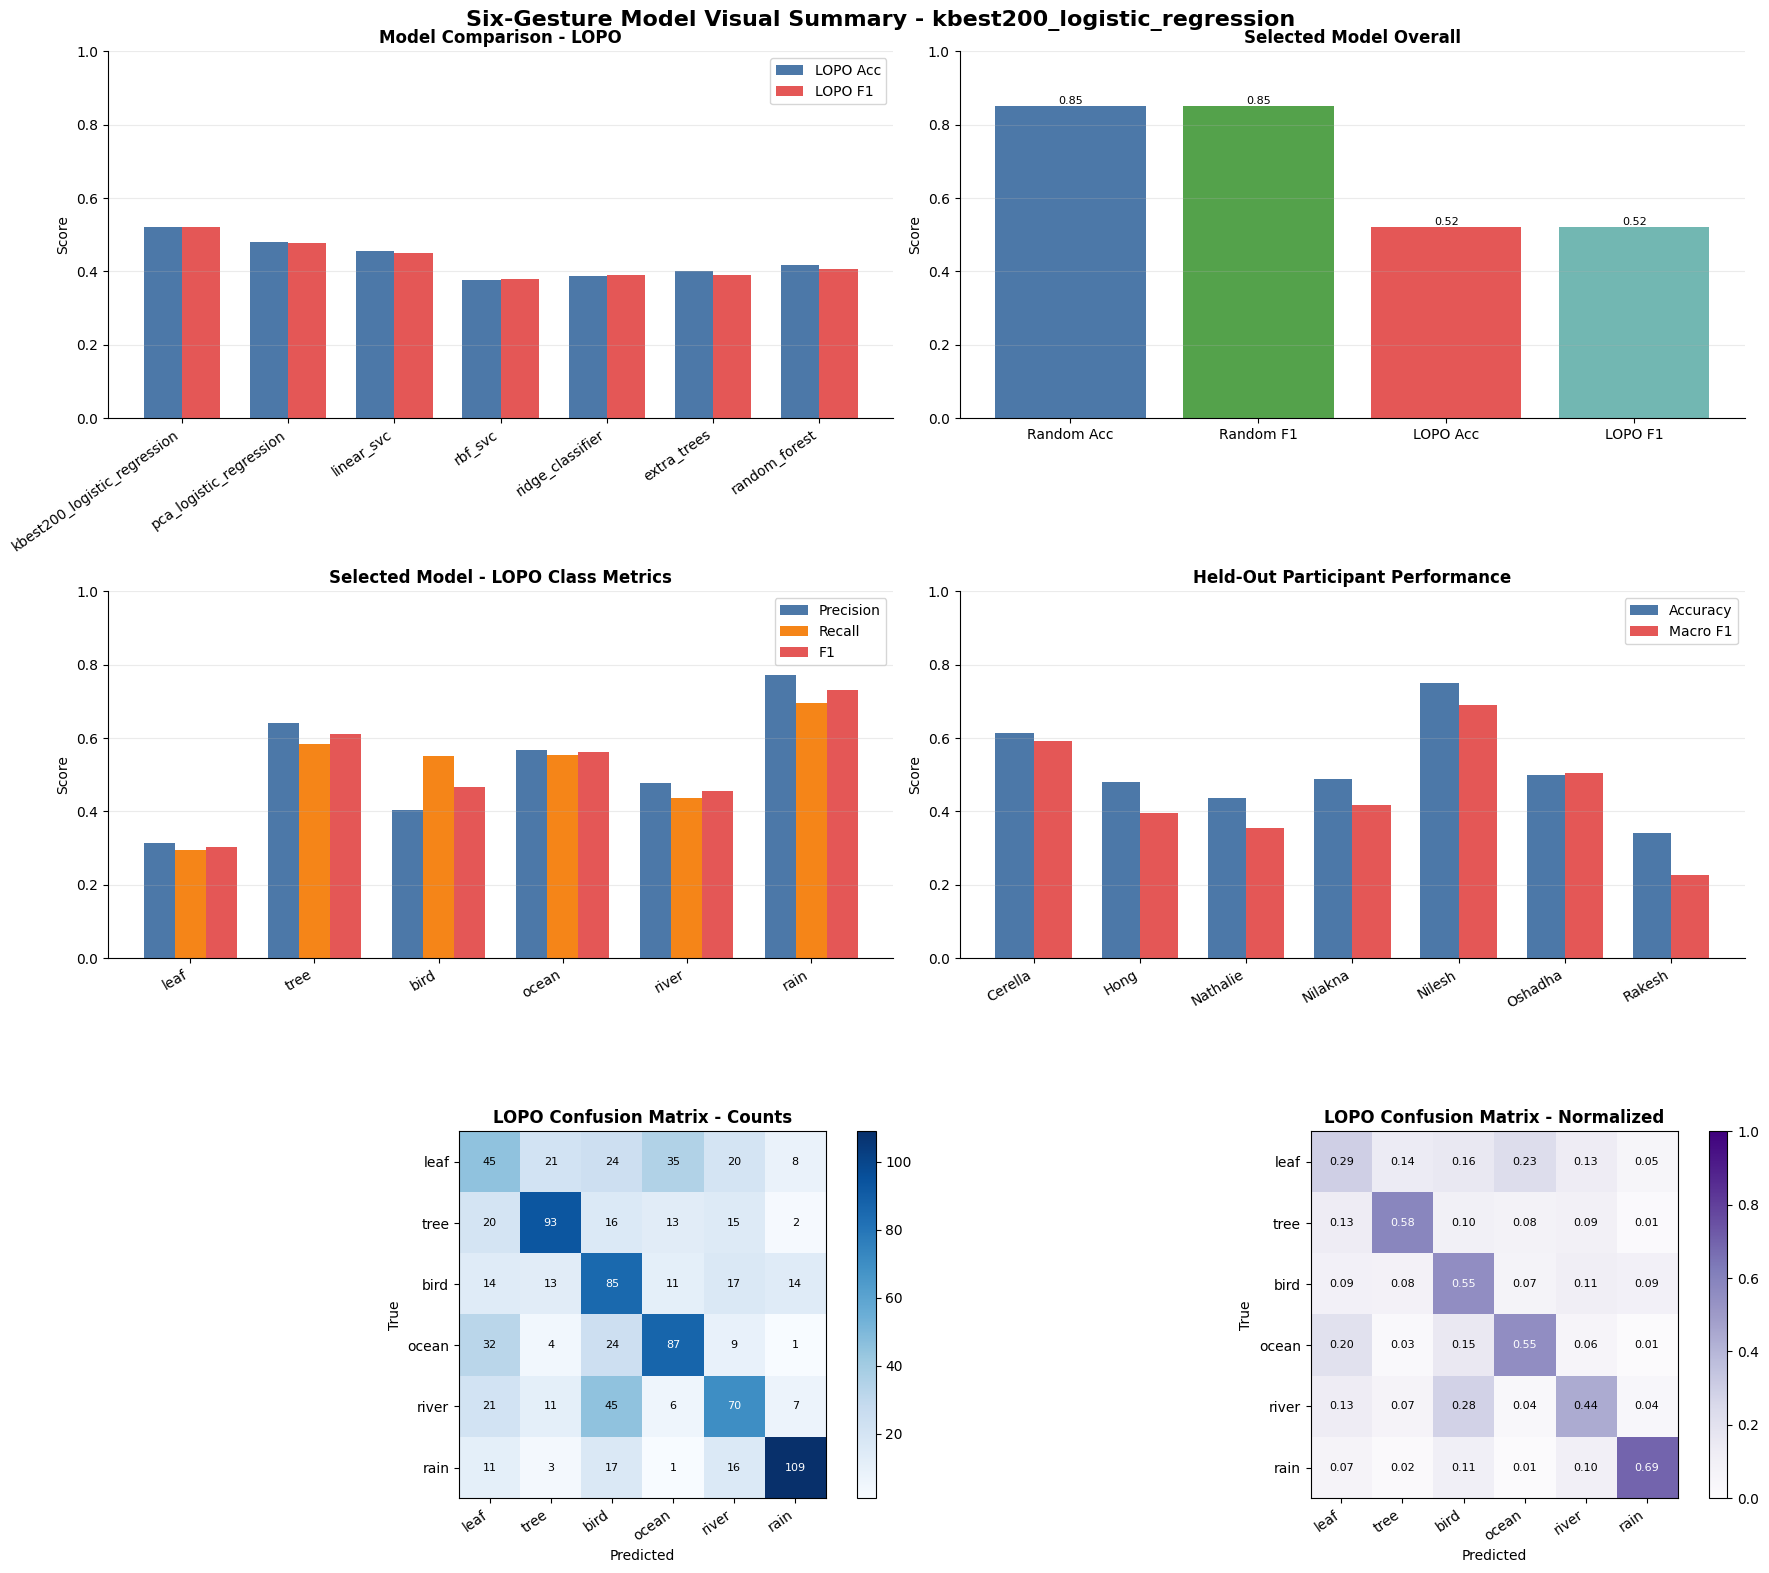

In [20]:
fig = plt.figure(figsize=(18, 16))
grid = fig.add_gridspec(3, 2)

ax1 = fig.add_subplot(grid[0, 0])
xpos = np.arange(len(model_names))
ax1.bar(xpos - 0.18, lopo_acc, 0.36, label="LOPO Acc", color="#4C78A8")
ax1.bar(xpos + 0.18, lopo_f1, 0.36, label="LOPO F1", color="#E45756")
style_axes(ax1, "Model Comparison - LOPO", ylabel="Score")
ax1.set_ylim(0, 1)
ax1.set_xticks(xpos)
ax1.set_xticklabels(model_names, rotation=35, ha="right")
ax1.legend()

ax2 = fig.add_subplot(grid[0, 1])
overall_names = ["Random Acc", "Random F1", "LOPO Acc", "LOPO F1"]
overall_values = [
    selected_result["random_holdout"]["accuracy"],
    selected_result["random_holdout"]["macro_f1"],
    selected_result["leave_one_participant_out"]["accuracy"],
    selected_result["leave_one_participant_out"]["macro_f1"],
]
ax2.bar(overall_names, overall_values, color=["#4C78A8", "#54A24B", "#E45756", "#72B7B2"])
style_axes(ax2, "Selected Model Overall", ylabel="Score")
ax2.set_ylim(0, 1)
add_bar_labels(ax2)

ax3 = fig.add_subplot(grid[1, 0])
xpos = np.arange(len(labels))
ax3.bar(xpos - 0.25, lopo_precision_by_class, 0.25, label="Precision", color="#4C78A8")
ax3.bar(xpos, lopo_recall_by_class, 0.25, label="Recall", color="#F58518")
ax3.bar(xpos + 0.25, lopo_f1_by_class, 0.25, label="F1", color="#E45756")
style_axes(ax3, "Selected Model - LOPO Class Metrics", ylabel="Score")
ax3.set_ylim(0, 1)
ax3.set_xticks(xpos)
ax3.set_xticklabels(labels, rotation=30, ha="right")
ax3.legend()

ax4 = fig.add_subplot(grid[1, 1])
xpos = np.arange(len(participant_names))
ax4.bar(xpos - 0.18, participant_acc, 0.36, label="Accuracy", color="#4C78A8")
ax4.bar(xpos + 0.18, participant_f1, 0.36, label="Macro F1", color="#E45756")
style_axes(ax4, "Held-Out Participant Performance", ylabel="Score")
ax4.set_ylim(0, 1)
ax4.set_xticks(xpos)
ax4.set_xticklabels(participant_names, rotation=30, ha="right")
ax4.legend()

ax5 = fig.add_subplot(grid[2, 0])
raw_matrix = np.array(selected_result["leave_one_participant_out"]["confusion_matrix"])
image = ax5.imshow(raw_matrix, cmap="Blues")
ax5.set_title("LOPO Confusion Matrix - Counts", fontsize=12, weight="bold")
ax5.set_xticks(np.arange(len(labels)))
ax5.set_yticks(np.arange(len(labels)))
ax5.set_xticklabels(labels, rotation=35, ha="right")
ax5.set_yticklabels(labels)
ax5.set_xlabel("Predicted")
ax5.set_ylabel("True")
threshold = raw_matrix.max() / 2
for row in range(raw_matrix.shape[0]):
    for col in range(raw_matrix.shape[1]):
        ax5.text(col, row, int(raw_matrix[row, col]), ha="center", va="center", color="white" if raw_matrix[row, col] > threshold else "black", fontsize=8)
fig.colorbar(image, ax=ax5, fraction=0.046, pad=0.04)

ax6 = fig.add_subplot(grid[2, 1])
norm_matrix = normalized_confusion(selected_result["leave_one_participant_out"]["confusion_matrix"])
image = ax6.imshow(norm_matrix, cmap="Purples", vmin=0, vmax=1)
ax6.set_title("LOPO Confusion Matrix - Normalized", fontsize=12, weight="bold")
ax6.set_xticks(np.arange(len(labels)))
ax6.set_yticks(np.arange(len(labels)))
ax6.set_xticklabels(labels, rotation=35, ha="right")
ax6.set_yticklabels(labels)
ax6.set_xlabel("Predicted")
ax6.set_ylabel("True")
for row in range(norm_matrix.shape[0]):
    for col in range(norm_matrix.shape[1]):
        ax6.text(col, row, f"{norm_matrix[row, col]:.2f}", ha="center", va="center", color="white" if norm_matrix[row, col] > 0.5 else "black", fontsize=8)
fig.colorbar(image, ax=ax6, fraction=0.046, pad=0.04)

fig.suptitle(f"Six-Gesture Model Visual Summary - {selected_model_name}", fontsize=16, weight="bold")
fig.tight_layout()
plt.show()

## Save Final Model And Report

In [21]:
final_model = candidate_models()[selected_model_name]
final_model.fit(X, y)

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
with MODEL_PATH.open("wb") as handle:
    pickle.dump(
        {
            "model": final_model,
            "model_name": selected_model_name,
            "labels": labels,
            "channels": CHANNELS,
            "target_frames": TARGET_FRAMES,
            "sequence_frames": SEQUENCE_FRAMES,
            "training_source": DATASET_PATH.relative_to(ROOT).as_posix(),
            "training_sample_count": len(y),
            "feature_count": int(X.shape[1]),
            "generated_on": GENERATED_ON,
        },
        handle,
    )

report = {
    "schema_version": "1.0",
    "generated_on": GENERATED_ON,
    "training_source": DATASET_PATH.relative_to(ROOT).as_posix(),
    "sample_count": len(y),
    "feature_count": int(X.shape[1]),
    "labels": labels,
    "label_counts": {label: int(label_counts[label]) for label in labels},
    "participant_counts": {name: int(count) for name, count in sorted(participant_counts.items())},
    "selected_model": selected_model_name,
    "selection_metric": "leave_one_participant_out.macro_f1",
    "model_output": MODEL_PATH.relative_to(ROOT).as_posix(),
    "results": results,
}

REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PATH.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("saved model:", MODEL_PATH.relative_to(ROOT).as_posix())
print("saved report:", REPORT_PATH.relative_to(ROOT).as_posix())

saved model: models/six_gesture_final_model.pkl
saved report: outputs/six_gesture_model_report.json
